# we'll use the same model from the gradient ascent training and tries to forget the digit 7 using teacher student model

In [1]:
import os
import torch
from tqdm import tqdm

In [2]:
MODELS_DIR = "models"
DATASET_DIR = "dataset"

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("using device:", device)

using device: cuda


# Dataset

In [4]:
from torchvision import datasets, transforms  # pyright: ignore[reportMissingTypeStubs]

train_ds = datasets.MNIST(
    DATASET_DIR,
    train=True,
    download=True,
    transform=transforms.ToTensor(),
)

test_ds = datasets.MNIST(
    DATASET_DIR,
    train=False,
    transform=transforms.ToTensor(),
)

In [5]:
from torch.utils.data import Subset

forget_idx = [i for i, (_, label) in enumerate(train_ds) if label == 7] # type: ignore

retain_idx = [i for i, (_, label) in enumerate(train_ds) if label != 7] # type: ignore

forget_set: Subset[datasets.MNIST] = Subset(train_ds, forget_idx)  # pyright: ignore[reportUnknownVariableType]
retain_set: Subset[datasets.MNIST] = Subset(train_ds, retain_idx)  # pyright: ignore[reportUnknownVariableType]

# Model

In [6]:
from utils.model import MnistCNN as CNN

# KL-divergence-loss

In [7]:
from utils.loss import kl_distillation_loss

# Load teacher and student

In [8]:
LR = 1e-3
EPOCHS = 2
BATCH_SIZE = 128
KL_TEMP = 4.0

In [9]:
teacher = CNN().to(device)
teacher.load_state_dict(
    torch.load(
        os.path.join(MODELS_DIR, "full_model.pt"),
    )
)
teacher.eval()

for p in teacher.parameters():
    p.requires_grad = False

In [10]:
student = CNN().to(device)

optimizer = torch.optim.Adam(
    student.parameters(),
    lr=LR,
)

# Knowledge Distillation on Retain set

In [11]:
from torch.utils.data import DataLoader

retain_loader = DataLoader(
    retain_set,
    batch_size=BATCH_SIZE,
    shuffle=True,
)

for epoch in range(EPOCHS):
    student.train()
    for x, _ in tqdm(retain_loader, desc=f"Distillation [{epoch + 1}/{EPOCHS}]"):
        x = x.to(device)

        with torch.no_grad():
            teacher_logits = teacher(x)

        student_logits = student(x)
        loss = kl_distillation_loss(
            student_logits,
            teacher_logits,
            temperature=KL_TEMP
        )

        optimizer.zero_grad()
        loss.backward() # pyright: ignore[reportUnknownMemberType]
        optimizer.step() # pyright: ignore[reportUnknownMemberType]

torch.save(
    student.state_dict(),
    os.path.join(MODELS_DIR, "student_unlearned.pt"),
)

Distillation [2/2]: 100%|██████████| 420/420 [00:12<00:00, 33.96it/s]


# Eval after distilation

In [10]:
from torch.utils.data import DataLoader
from utils.eval import eval_model_accuracy, eval_avg_confidence, eval_model_roc_auc

forget_loader: DataLoader[datasets.MNIST] = DataLoader(  # pyright: ignore[reportUnknownVariableType]
    forget_set, batch_size=BATCH_SIZE, shuffle=False
)
retain_loader: DataLoader[datasets.MNIST] = DataLoader(  # pyright: ignore[reportUnknownVariableType]
    retain_set, batch_size=BATCH_SIZE, shuffle=False
)
test_loader: DataLoader[datasets.MNIST] = DataLoader(  # pyright: ignore[reportUnknownVariableType]
    test_ds, batch_size=BATCH_SIZE, shuffle=False
)

test_forget_idx = [i for i, (_, label) in enumerate(test_ds) if label == 7] # type: ignore
test_retain_idx = [i for i, (_, label) in enumerate(test_ds) if label != 7] # type: ignore

test_forget_set: Subset[datasets.MNIST] = Subset(test_ds, test_forget_idx)  # pyright: ignore[reportUnknownVariableType]
test_retain_set: Subset[datasets.MNIST] = Subset(test_ds, test_retain_idx)  # pyright: ignore[reportUnknownVariableType]

test_forget_loader: DataLoader[datasets.MNIST] = DataLoader(  # pyright: ignore[reportUnknownVariableType]
    test_forget_set, batch_size=BATCH_SIZE, shuffle=False
)
test_retain_loader: DataLoader[datasets.MNIST] = DataLoader(  # pyright: ignore[reportUnknownVariableType]
    test_retain_set, batch_size=BATCH_SIZE, shuffle=False
)


In [ ]:
model = CNN().to(device)
model.load_state_dict(
    torch.load(
        os.path.join(MODELS_DIR, "student_unlearned.pt"),
    )
)


def evaluate_split(
    name: str,
    loader: DataLoader[datasets.MNIST],
) -> None:
    acc = eval_model_accuracy(model, loader, device)
    conf = eval_avg_confidence(model, loader, device)
    auc = eval_model_roc_auc(model, loader, device)

    print(
        f"{name:<30}"
        f"Acc: {acc:>8.4f} | "
        f"AUC: {auc:>8.4f} | "
        f"Avg Conf: {conf:>8.4f}"
    )

print("\n" + "=" * 80)
print("MODEL EVALUATION")
print("=" * 80)

evaluate_split("Retain Train", retain_loader)
evaluate_split("Forget Train", forget_loader)

print("-" * 80)

evaluate_split("Test (All)", test_loader)
evaluate_split("Test Retain", test_retain_loader)
evaluate_split("Test Forget", test_forget_loader)

print("=" * 80)


MODEL EVALUATION
Retain Train                  Acc:   0.9933 | AUC:   1.0000 | Avg Conf:   0.9935
Forget Train                  Acc:   0.6873 | AUC:      nan | Avg Conf:   0.8778
--------------------------------------------------------------------------------
Test (All)                    Acc:   0.9593 | AUC:   0.9997 | Avg Conf:   0.9798
Test Retain                   Acc:   0.9886 | AUC:   0.9999 | Avg Conf:   0.9922
Test Forget                   Acc:   0.7033 | AUC:      nan | Avg Conf:   0.8719


# Visualization & Presentation Graphs
This section generates presentation-quality plots comparing the **Original Model** and the **Unlearned Model**.

In [11]:
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set high-quality styling for presentation
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({
    'font.size': 12,
    'axes.labelsize': 14,
    'axes.titlesize': 16,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'figure.titlesize': 18
})

# Load Original and Unlearned Models
original_model = CNN().to(device)
original_model.load_state_dict(torch.load("models/full_model.pt", map_location=device))
original_model.eval()

unlearned_model = CNN().to(device)
unlearned_model.load_state_dict(torch.load("models/student_unlearned.pt", map_location=device))
unlearned_model.eval()

# Compute predictions and confidence scores
def get_predictions_and_confidences(model, loader):
    all_confs = []
    all_preds = []
    all_targets = []
    correct_count = 0
    total_count = 0
    
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            logits = model(x)
            probs = F.softmax(logits, dim=1)
            
            confs, preds = probs.max(dim=1)
            all_confs.extend(confs.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())
            all_targets.extend(y.cpu().numpy())
            
            correct_count += (preds == y).sum().item()
            total_count += y.size(0)
            
    accuracy = correct_count / total_count
    return accuracy, np.array(all_confs), np.array(all_preds), np.array(all_targets)

print("Computing statistics...")
orig_retain_acc, orig_retain_confs, orig_retain_preds, _ = get_predictions_and_confidences(original_model, test_retain_loader)
orig_forget_acc, orig_forget_confs, orig_forget_preds, _ = get_predictions_and_confidences(original_model, test_forget_loader)

unlearn_retain_acc, unlearn_retain_confs, unlearn_retain_preds, _ = get_predictions_and_confidences(unlearned_model, test_retain_loader)
unlearn_forget_acc, unlearn_forget_confs, unlearn_forget_preds, _ = get_predictions_and_confidences(unlearned_model, test_forget_loader)
print("Done!")


Computing statistics...
Done!


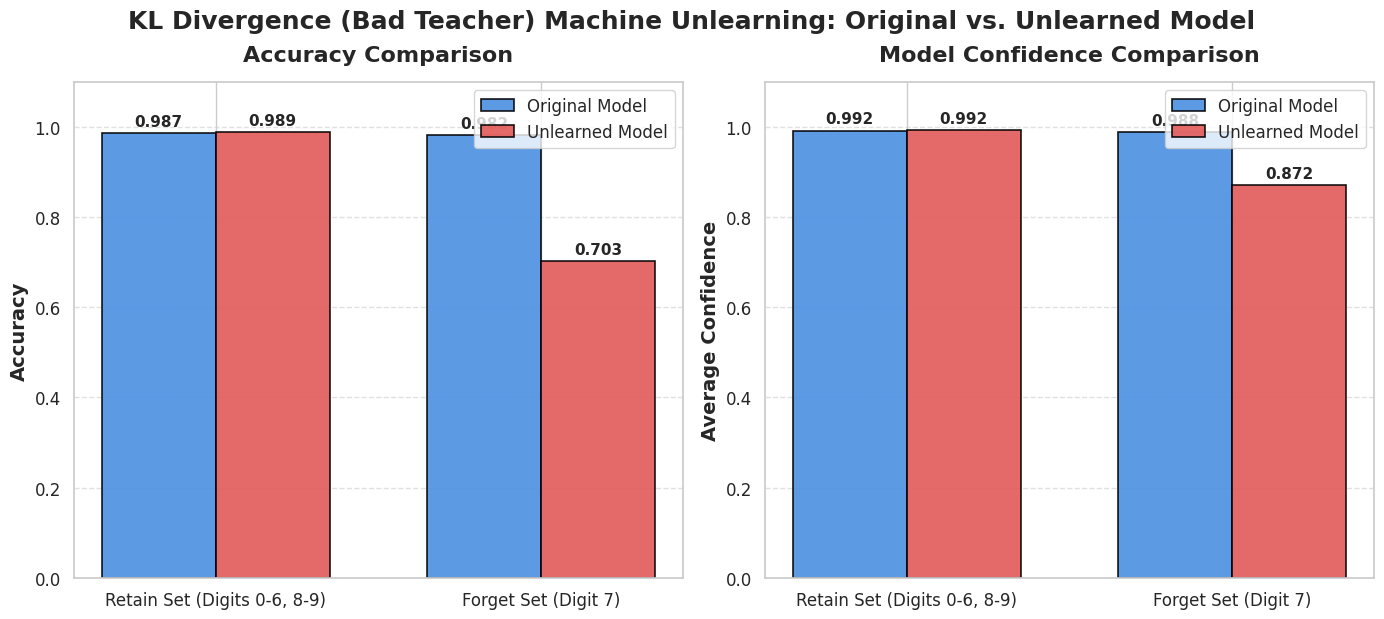

In [12]:
# Plot 1: Performance comparison bar charts
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Elegant professional colors
colors = ['#4A90E2', '#E25A5A']  # Soft blue and coral

labels = ['Retain Set (Digits 0-6, 8-9)', 'Forget Set (Digit 7)']
x = np.arange(len(labels))
width = 0.35

# Plot Accuracies
axes[0].bar(x - width/2, [orig_retain_acc, orig_forget_acc], width, label='Original Model', color=colors[0], alpha=0.9, edgecolor='black', linewidth=1.2)
axes[0].bar(x + width/2, [unlearn_retain_acc, unlearn_forget_acc], width, label='Unlearned Model', color=colors[1], alpha=0.9, edgecolor='black', linewidth=1.2)
axes[0].set_ylabel('Accuracy', fontsize=14, fontweight='semibold')
axes[0].set_title('Accuracy Comparison', fontsize=16, fontweight='bold', pad=15)
axes[0].set_xticks(x)
axes[0].set_xticklabels(labels, fontsize=12)
axes[0].set_ylim(0, 1.1)
axes[0].legend(loc='upper right', fontsize=12)
axes[0].grid(axis='y', linestyle='--', alpha=0.6)

# Add values on top of bars
for bar in axes[0].containers:
    axes[0].bar_label(bar, fmt='%.3f', label_type='edge', padding=3, fontsize=11, fontweight='semibold')

# Plot Confidences
axes[1].bar(x - width/2, [orig_retain_confs.mean(), orig_forget_confs.mean()], width, label='Original Model', color=colors[0], alpha=0.9, edgecolor='black', linewidth=1.2)
axes[1].bar(x + width/2, [unlearn_retain_confs.mean(), unlearn_forget_confs.mean()], width, label='Unlearned Model', color=colors[1], alpha=0.9, edgecolor='black', linewidth=1.2)
axes[1].set_ylabel('Average Confidence', fontsize=14, fontweight='semibold')
axes[1].set_title('Model Confidence Comparison', fontsize=16, fontweight='bold', pad=15)
axes[1].set_xticks(x)
axes[1].set_xticklabels(labels, fontsize=12)
axes[1].set_ylim(0, 1.1)
axes[1].legend(loc='upper right', fontsize=12)
axes[1].grid(axis='y', linestyle='--', alpha=0.6)

for bar in axes[1].containers:
    axes[1].bar_label(bar, fmt='%.3f', label_type='edge', padding=3, fontsize=11, fontweight='semibold')

plt.tight_layout()
plt.suptitle('KL Divergence (Bad Teacher) Machine Unlearning: Original vs. Unlearned Model', y=1.03, fontsize=18, fontweight='bold')
plt.show()


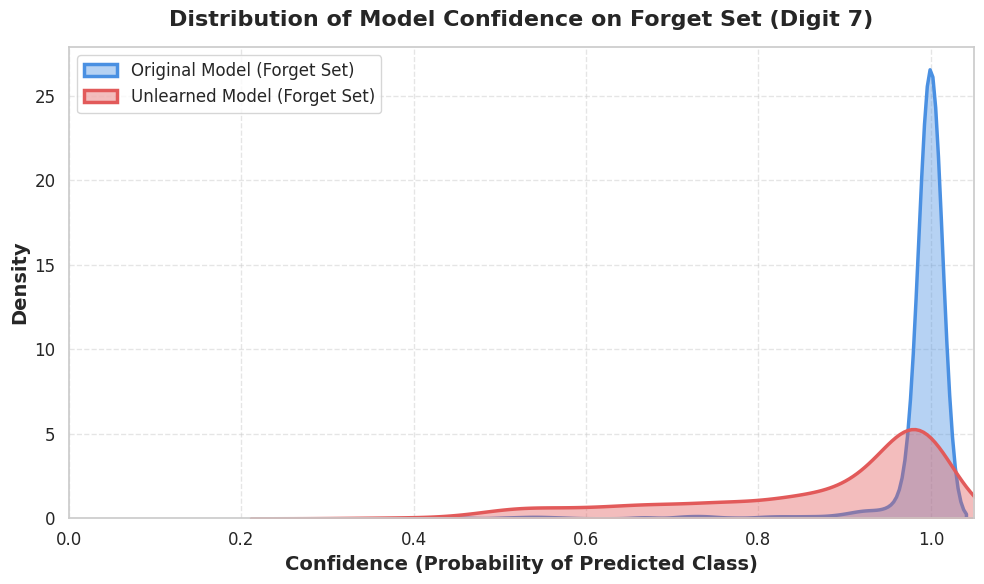

In [13]:
# Plot 2: Confidence Distribution (KDE) on Forget Set
plt.figure(figsize=(10, 6))

sns.kdeplot(orig_forget_confs, fill=True, label="Original Model (Forget Set)", color="#4A90E2", alpha=0.4, linewidth=2.5)
sns.kdeplot(unlearn_forget_confs, fill=True, label="Unlearned Model (Forget Set)", color="#E25A5A", alpha=0.4, linewidth=2.5)

plt.title("Distribution of Model Confidence on Forget Set (Digit 7)", fontsize=16, fontweight='bold', pad=15)
plt.xlabel("Confidence (Probability of Predicted Class)", fontsize=14, fontweight='semibold')
plt.ylabel("Density", fontsize=14, fontweight='semibold')
plt.xlim(0.0, 1.05)
plt.legend(fontsize=12, loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()


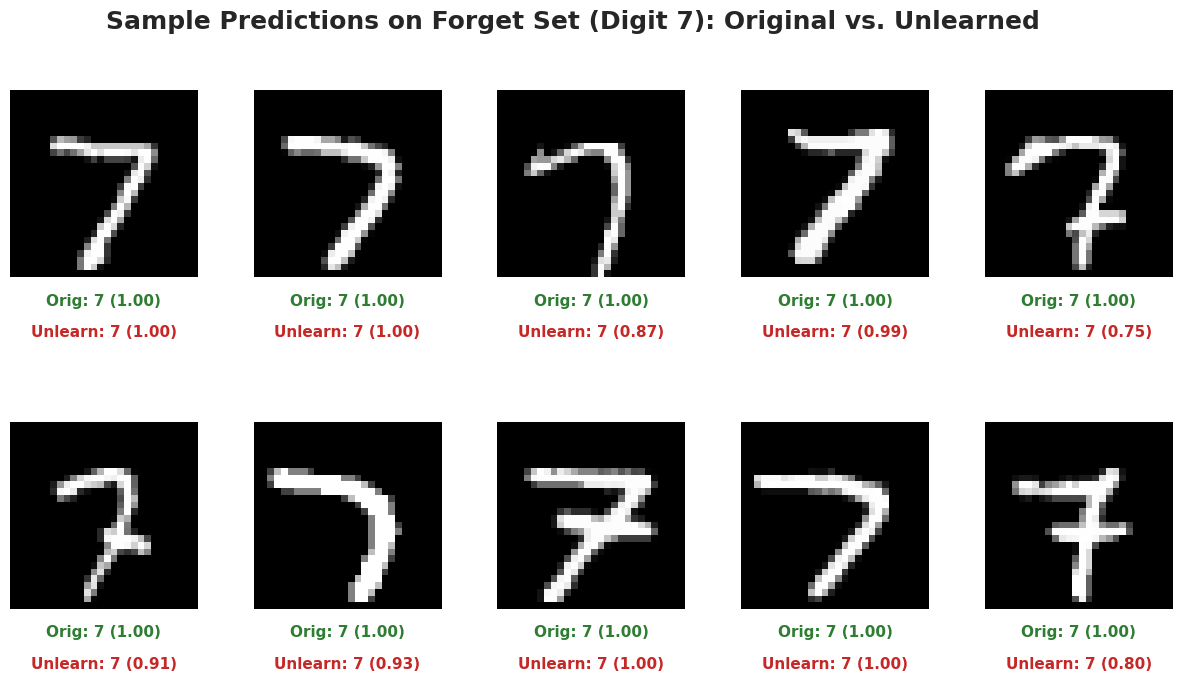

In [14]:
# Plot 3: Qualitative Test: Sample predictions on Forget Set (Digit 7)
forget_images = []
forget_labels = []

# Retrieve samples from loader
for x, y in test_forget_loader:
    forget_images.append(x)
    forget_labels.append(y)
    if len(forget_images) * 128 > 10:  # We need at least 10 samples
        break

forget_images = torch.cat(forget_images)[:10]
forget_labels = torch.cat(forget_labels)[:10]

with torch.no_grad():
    # Original model predictions
    orig_logits = original_model(forget_images.to(device))
    orig_probs = F.softmax(orig_logits, dim=1)
    orig_confs, orig_preds = orig_probs.max(dim=1)
    
    # Unlearned model predictions
    unlearn_logits = unlearned_model(forget_images.to(device))
    unlearn_probs = F.softmax(unlearn_logits, dim=1)
    unlearn_confs, unlearn_preds = unlearn_probs.max(dim=1)

# Plot the 10 samples with prediction text
fig, axes = plt.subplots(2, 5, figsize=(15, 7))
axes = axes.flatten()

for i in range(10):
    img = forget_images[i].squeeze().numpy()
    axes[i].imshow(img, cmap='gray')
    axes[i].axis('off')
    
    orig_txt = f"Orig: {orig_preds[i].item()} ({orig_confs[i].item():.2f})"
    unlearn_txt = f"Unlearn: {unlearn_preds[i].item()} ({unlearn_confs[i].item():.2f})"
    
    # Coloring prediction labels: for unlearning, we want the model to NOT predict 7 (so predicting 7 is red, other is green)
    orig_color = '#2E7D32' if orig_preds[i].item() == 7 else '#C62828'
    unlearn_color = '#C62828' if unlearn_preds[i].item() == 7 else '#2E7D32'
    
    axes[i].text(0.5, -0.15, orig_txt, transform=axes[i].transAxes, 
                 ha="center", color=orig_color, fontweight='bold', fontsize=11)
    axes[i].text(0.5, -0.32, unlearn_txt, transform=axes[i].transAxes, 
                 ha="center", color=unlearn_color, fontweight='bold', fontsize=11)

plt.subplots_adjust(wspace=0.3, hspace=0.6)
plt.suptitle("Sample Predictions on Forget Set (Digit 7): Original vs. Unlearned", y=0.98, fontsize=18, fontweight='bold')
plt.show()
